Columns in dataset:
['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason']

Churn column found: Churn Category


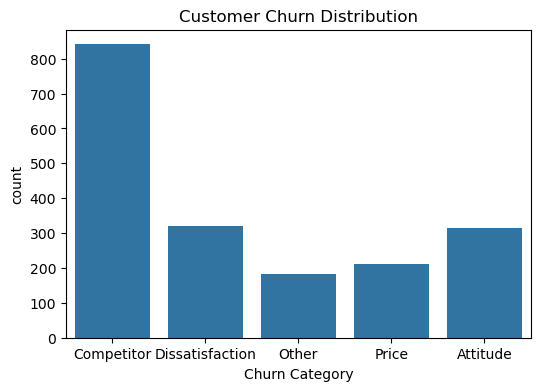

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_csv("telecom_customer_churn.csv")


# Show columns
print("Columns in dataset:")
print(df.columns.tolist())


# Find churn column automatically
churn_col = None

for col in df.columns:
    if "churn" in col.lower():
        churn_col = col
        break


print("\nChurn column found:", churn_col)


# Plot churn distribution
if churn_col:
    plt.figure(figsize=(6,4))

    sns.countplot(
        x=churn_col,
        data=df
    )

    plt.title("Customer Churn Distribution")
    plt.show()

else:
    print("No churn column found. Check column names.")

In [9]:
# Check dataset information

print("Dataset Shape:")
print(df.shape)


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDuplicate Rows:")
print(df.duplicated().sum())


# Convert charges columns to numeric
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)


# Check data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(7043, 38)

Missing Values:
Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                     

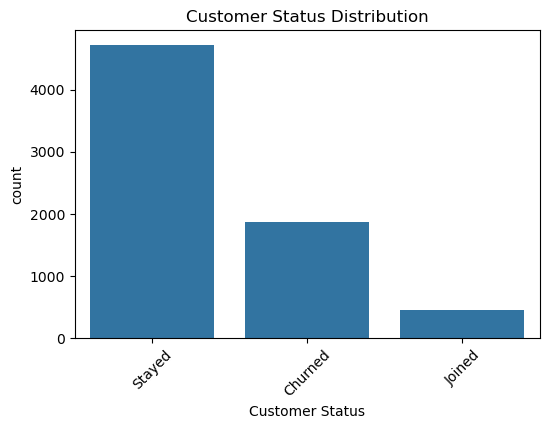

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


# Customer Status distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Customer Status',
    data=df
)

plt.title("Customer Status Distribution")
plt.xticks(rotation=45)
plt.show()

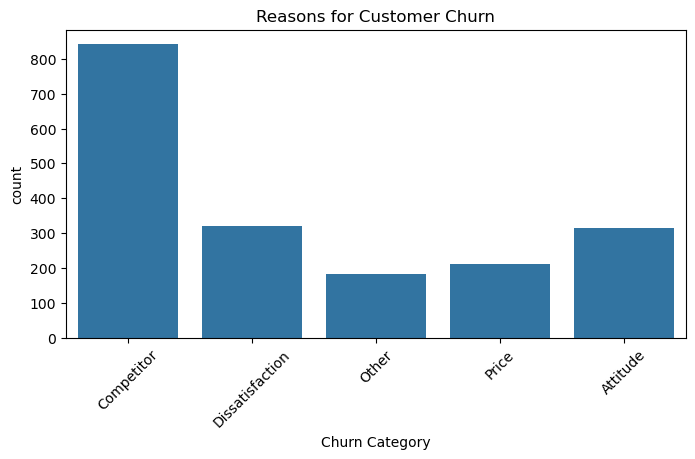

In [13]:
plt.figure(figsize=(8,4))

sns.countplot(
    x='Churn Category',
    data=df
)

plt.title("Reasons for Customer Churn")
plt.xticks(rotation=45)
plt.show()

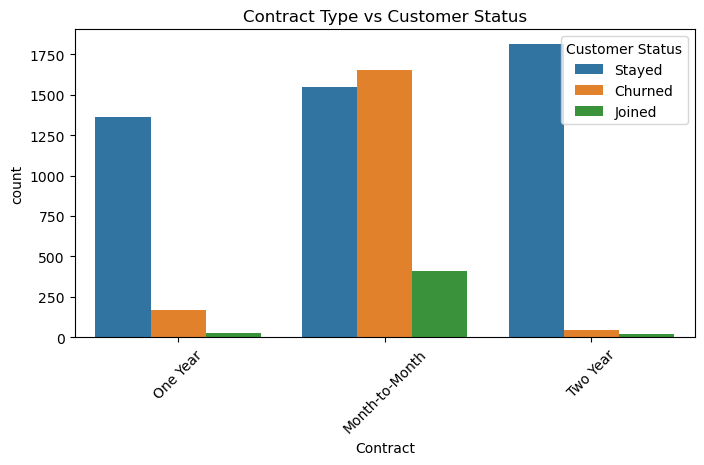

In [15]:
plt.figure(figsize=(8,4))

sns.countplot(
    x='Contract',
    hue='Customer Status',
    data=df
)

plt.title("Contract Type vs Customer Status")
plt.xticks(rotation=45)
plt.show()

In [37]:
print(df['Customer Status'].value_counts())

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [39]:
# Create ML dataset

ml_df = df.copy()


# Remove new customers
ml_df = ml_df[ml_df['Customer Status'] != 'Joined']


# Create churn flag
ml_df['Churn_Flag'] = ml_df['Customer Status'].apply(
    lambda x: 1 if x == 'Churned' else 0
)


# Check target balance
print(ml_df['Churn_Flag'].value_counts())

Churn_Flag
0    4720
1    1869
Name: count, dtype: int64


In [41]:
# Remove unnecessary columns

ml_df.drop(
    ['Customer ID','Customer Status'],
    axis=1,
    inplace=True
)


# Convert categorical data into numbers

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ml_df.columns:
    if ml_df[col].dtype == 'object':
        ml_df[col] = encoder.fit_transform(ml_df[col])


# Remove missing values

ml_df.dropna(inplace=True)


ml_df.head()

,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Category,Churn Reason,Churn_Flag
0,0,37,1,0,346,93225,34.827662,-118.999073,2,9,...,1,65.6,593.30,0.00,0,381.51,974.81,5,20,0
1,1,46,0,0,368,91206,34.162515,-118.203869,0,9,...,1,-4.0,542.40,38.33,10,96.21,610.28,5,20,0
2,1,50,0,0,222,92627,33.645672,-117.922613,0,4,...,0,73.9,280.85,0.00,0,134.60,415.45,1,2,1
3,1,78,1,0,587,94553,38.014457,-122.115432,1,13,...,0,98.0,1237.85,0.00,0,361.66,1599.51,2,18,1
4,0,75,1,0,139,93010,34.227846,-119.079903,3,3,...,1,83.9,267.40,0.00,0,22.14,289.54,2,14,1


In [43]:
from sklearn.model_selection import train_test_split


X = ml_df.drop(
    'Churn_Flag',
    axis=1
)

y = ml_df['Churn_Flag']


X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(y_train.value_counts())

Churn_Flag
0    2411
1    1269
Name: count, dtype: int64


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Create model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# Train model

model.fit(
    X_train,
    y_train
)


# Prediction

y_pred = model.predict(X_test)


# Accuracy

print("Accuracy:")
print(accuracy_score(y_test,y_pred))


# Classification report

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred
))

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       604
           1       1.00      1.00      1.00       317

    accuracy                           1.00       921
   macro avg       1.00      1.00      1.00       921
weighted avg       1.00      1.00      1.00       921



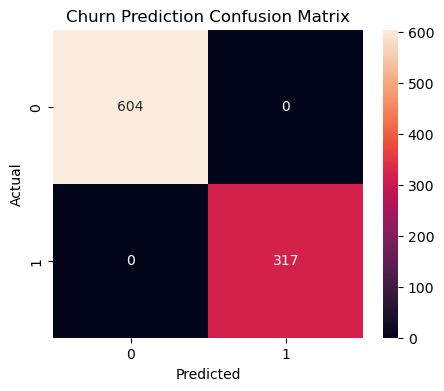

In [47]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Churn Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
# Create ML dataset

ml_df = df.copy()


# Remove joined customers
ml_df = ml_df[ml_df['Customer Status'] != 'Joined']


# Create churn flag
ml_df['Churn_Flag'] = ml_df['Customer Status'].apply(
    lambda x: 1 if x == 'Churned' else 0
)


# Remove leakage columns safely

remove_cols = [
    'Customer ID',
    'Customer Status',
    'Churn Category',
    'Churn Reason',
    'Churn Score'
]


ml_df.drop(
    columns=[col for col in remove_cols if col in ml_df.columns],
    inplace=True
)


# Encode categorical columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()


for col in ml_df.columns:
    if ml_df[col].dtype == 'object':
        ml_df[col] = encoder.fit_transform(ml_df[col])


# Remove missing values

ml_df.dropna(inplace=True)


print("Data ready")
print(ml_df.head())

Data ready
   Gender  Age  Married  Number of Dependents  City  Zip Code   Latitude  \
0       0   37        1                     0   346     93225  34.827662   
1       1   46        0                     0   368     91206  34.162515   
2       1   50        0                     0   222     92627  33.645672   
3       1   78        1                     0   587     94553  38.014457   
4       0   75        1                     0   139     93010  34.227846   

    Longitude  Number of Referrals  Tenure in Months  ...  Contract  \
0 -118.999073                    2                 9  ...         1   
1 -118.203869                    0                 9  ...         0   
2 -117.922613                    0                 4  ...         0   
3 -122.115432                    1                13  ...         0   
4 -119.079903                    3                 3  ...         0   

   Paperless Billing  Payment Method  Monthly Charge  Total Charges  \
0                  1              

In [53]:
from sklearn.model_selection import train_test_split


X = ml_df.drop(
    'Churn_Flag',
    axis=1
)

y = ml_df['Churn_Flag']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(y_train.value_counts())

Churn_Flag
0    2411
1    1269
Name: count, dtype: int64


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


model.fit(
    X_train,
    y_train
)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test,y_pred))


print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.8317046688382194
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       604
           1       0.80      0.68      0.74       317

    accuracy                           0.83       921
   macro avg       0.82      0.80      0.81       921
weighted avg       0.83      0.83      0.83       921



                        Feature  Importance
25                     Contract    0.106420
9              Tenure in Months    0.105304
33                Total Revenue    0.083694
29                Total Charges    0.082216
8           Number of Referrals    0.064792
28               Monthly Charge    0.059188
32  Total Long Distance Charges    0.053880
1                           Age    0.044635
4                          City    0.037225
6                      Latitude    0.037191


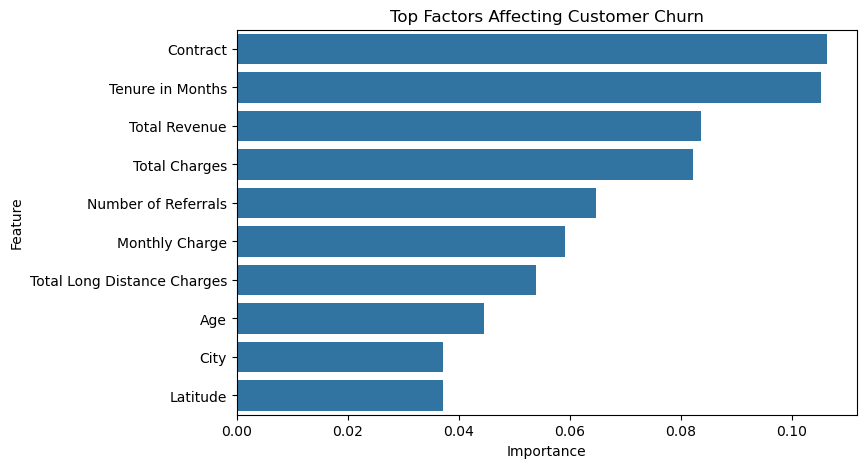

In [57]:
# Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Get feature importance

importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': model.feature_importances_

})


# Sort values

importance = importance.sort_values(
    by='Importance',
    ascending=False
)


# Display top features

print(importance.head(10))


# Plot

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)


plt.title("Top Factors Affecting Customer Churn")

plt.show()

In [59]:
import joblib


# Save trained model

joblib.dump(
    model,
    "telecom_churn_model.pkl"
)


print("Model saved successfully!")

Model saved successfully!


In [61]:
ml_df.to_csv(
    "processed_telecom_churn_data.csv",
    index=False
)

print("Dataset saved!")

Dataset saved!
